# NHANES 2017–2018 — Modelo de señales de hipertensión con regresión logística y random forest

Esta notebook reconstruye el caso de hipertensión desde el **CSV raw original** y ejecuta el ciclo completo de modelado:

1. validación del dataset y de variables esperadas;
2. limpieza de códigos especiales de cuestionarios;
3. construcción justificada de la etiqueta `hypertension_130_80`;
4. control explícito de fuga de información;
5. partición train/validation/test;
6. preprocesamiento con `Pipeline` y `ColumnTransformer`;
7. entrenamiento y comparación de **regresión logística** y **random forest**;
8. evaluación con métricas ponderadas por `WTMEC2YR` y no ponderadas;
9. interpretación de gráficos, métricas, umbrales e importancia de variables;
10. listado de tareas para producción dentro de un ciclo de modelado de sistemas de IA.

> **Alcance clínico:** el modelo no diagnostica hipertensión. NHANES es transversal y el objetivo aquí es detectar **señales compatibles con hipertensión** en una población adulta usando variables cardiometabólicas disponibles, evitando usar como predictores las mediciones de presión arterial o las preguntas que definen directamente la etiqueta.

## 0. Fuentes oficiales usadas y decisiones que justifican

| Tema | Fuente oficial | Uso en esta notebook |
|---|---|---|
| Ciclo NHANES 2017–2018 | CDC/NCHS — NHANES 2017–2018 Overview: https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/overview.aspx?BeginYear=2017 | Valida el contexto del dataset y el tamaño esperado del ciclo. |
| Diseño, pesos y variables demográficas | CDC/NCHS — `DEMO_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.htm | Justifica `RIDAGEYR`, `RIAGENDR`, `RIDRETH3`, `WTMEC2YR`, `SDMVSTRA`, `SDMVPSU`. |
| Uso de pesos muestrales | CDC/NCHS — NHANES Weighting Tutorial: https://wwwn.cdc.gov/nchs/nhanes/tutorials/weighting.aspx | Justifica usar `WTMEC2YR` como `sample_weight` en entrenamiento y métricas. |
| Diseño complejo de encuesta | CDC/NCHS — Sample Design Module: https://wwwn.cdc.gov/nchs/nhanes/tutorials/sampledesign.aspx | Documenta la limitación: scikit-learn usa pesos pero no estima varianza con estratos/PSU. |
| Mediciones de presión arterial | CDC/NCHS — `BPX_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPX_J.htm | Justifica el uso de varias lecturas sistólicas y diastólicas para construir la etiqueta. |
| Cuestionario presión/colesterol | CDC/NCHS — `BPQ_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BPQ_J.htm | Justifica `BPQ020` y `BPQ050A` como variables de awareness/tratamiento; no se usan como features. |
| Umbral clínico de referencia | CDC — About High Blood Pressure: https://www.cdc.gov/high-blood-pressure/about/index.html | Justifica `SBP >= 130` o `DBP >= 80` como presión arterial alta. |
| Definición operativa con medicación | CDC/NCHS — Data Brief No. 511: https://www.cdc.gov/nchs/products/databriefs/db511.htm | Justifica definir hipertensión como sistólica ≥130, diastólica ≥80 o medicación actual para bajar presión. |
| Clasificación clínica complementaria | American Heart Association — Understanding Blood Pressure Readings: https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings | Complementa la interpretación de etapa 1 o mayor. |
| Antropometría | CDC/NCHS — `BMX_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.htm | Justifica `BMXBMI` y `BMXWAIST`. |
| Colesterol total | CDC/NCHS — `TCHOL_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/TCHOL_J.htm | Justifica `LBXTC`. |
| HDL | CDC/NCHS — `HDL_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/HDL_J.htm | Justifica `LBDHDD`. |
| HbA1c | CDC/NCHS — `GHB_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.htm | Justifica `LBXGH`. |
| Tabaquismo | CDC/NCHS — `SMQ_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SMQ_J.htm | Justifica derivar `current_smoker` desde `SMQ020` y `SMQ040`. |
| Diabetes | CDC/NCHS — `DIQ_J`: https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DIQ_J.htm | Se conserva como referencia de riesgo cardiometabólico, aunque no se usa como feature final para evitar ambigüedad de disponibilidad. |
| Regresión logística | scikit-learn — `LogisticRegression`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html | Justifica un clasificador lineal regularizado y probabilístico. |
| Random forest | scikit-learn — `RandomForestClassifier`: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html | Justifica un ensamble de árboles para capturar no linealidades e interacciones. |
| Ciclo de riesgo de IA | NIST AI RMF — Core: https://airc.nist.gov/airmf-resources/airmf/5-sec-core/ | Estructura el checklist de producción en Govern, Map, Measure y Manage. |

**Decisión central:** la etiqueta se construye con presión arterial medida y medicación antihipertensiva, pero esas variables se excluyen de las entradas del modelo para evitar `data leakage`.

## 1. Importación de librerías y configuración reproducible

Para la etapa de ciencias de datos usamos las siguientes librerías:

- `pandas`
- `numpy`
- `matplotlib`

Para la etapa de modelado y entrenamiento del modelo, usamos `scikit-learn` creando un flujo reproducible.

Establecimos un valor explícito de `random_state` par asegurar la reproducibilidad de las particiones y modelos entre ejecuciones.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn import __version__ as sklearn_version
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "hypertension_130_80"

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print(f"scikit-learn version: {sklearn_version}")

scikit-learn version: 1.8.0


## 2. Carga del CSV raw original

La notebook busca el CSV en varias rutas posibles para funcionar tanto dentro de este entorno como en una carpeta local. El archivo entregado en esta ejecución se llama `nhanes_2017_2018_cardiometabolic_raw(2).csv`.

In [2]:
csv_path = Path("nhanes_2017_2018_cardiometabolic_raw.csv")

if not csv_path.exists():
    raise FileNotFoundError(
        "No encontré el CSV raw. Coloca el archivo nhanes_2017_2018_cardiometabolic_raw.csv "
        "en la misma carpeta que esta notebook."
    )

raw = pd.read_csv(csv_path)

print(f"Archivo cargado: {csv_path}")
print(f"Filas: {raw.shape[0]:,}")
print(f"Columnas: {raw.shape[1]:,}")
display(raw.head())

Archivo cargado: nhanes_2017_2018_cardiometabolic_raw.csv
Filas: 9,254
Columnas: 30


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH3,INDFMPIR,WTMEC2YR,SDMVSTRA,SDMVPSU,BMXBMI,BMXWAIST,BPXSY1,BPXDI1,BPXSY2,BPXDI2,BPXSY3,BPXDI3,BPXSY4,BPXDI4,LBXTC,LBDHDD,LBXGH,SMQ020,SMQ040,BPQ020,BPQ050A,BPQ080,BPQ100D,DIQ010,DIQ160
0,93703,10,2,2,6,5.0000,"8,539.7313",145,2,17.5000,48.2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,NaN
1,93704,10,2,1,3,5.0000,"42,566.6147",143,1,15.7000,50.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,NaN
2,93705,10,66,2,4,0.8200,"8,338.4198",145,2,31.7000,101.8000,NaN,NaN,NaN,NaN,202.0000,62.0000,198.0000,74.0000,157.0000,60.0000,6.2000,1.0000,3.0000,1.0000,1.0000,2.0000,NaN,2.0000,2.0000
3,93706,10,18,1,6,NaN,"8,723.4398",134,2,21.5000,79.3000,112.0000,74.0000,114.0000,70.0000,108.0000,76.0000,NaN,NaN,148.0000,47.0000,5.2000,2.0000,NaN,2.0000,NaN,2.0000,NaN,2.0000,2.0000
4,93707,10,13,1,7,1.8800,"7,064.6097",138,1,18.1000,64.1000,128.0000,38.0000,128.0000,46.0000,128.0000,58.0000,NaN,NaN,189.0000,68.0000,5.6000,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,2.0000


## 3. Validación mínima de estructura

Antes de derivar variables, verificamos que estén las columnas esperadas. Esto evita entrenar un modelo con un archivo incompleto, un join defectuoso o nombres de variables cambiados.

Las variables `WTMEC2YR`, `SDMVSTRA` y `SDMVPSU` se conservan porque NHANES usa un diseño muestral complejo. En `scikit-learn` usaremos `WTMEC2YR` como peso muestral, pero dejaremos documentada la limitación de no estimar varianza con estratos y PSU dentro de este flujo estándar de machine learning.

In [3]:
expected_columns = [
    "SEQN",
    "SDDSRVYR",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "INDFMPIR",
    "WTMEC2YR",
    "SDMVSTRA",
    "SDMVPSU",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "BPXSY2",
    "BPXDI2",
    "BPXSY3",
    "BPXDI3",
    "BPXSY4",
    "BPXDI4",
    "LBXTC",
    "LBDHDD",
    "LBXGH",
    "SMQ020",
    "SMQ040",
    "BPQ020",
    "BPQ050A",
    "BPQ080",
    "BPQ100D",
    "DIQ010",
    "DIQ160",
]

validation = pd.DataFrame(
    {
        "chequeo": [
            "filas",
            "columnas",
            "SEQN único",
            "SEQN duplicados",
            "columnas esperadas faltantes",
            "WTMEC2YR > 0",
            "ciclos SDDSRVYR presentes",
        ],
        "resultado": [
            raw.shape[0],
            raw.shape[1],
            bool(raw["SEQN"].is_unique) if "SEQN" in raw.columns else None,
            int(raw.duplicated("SEQN").sum()) if "SEQN" in raw.columns else None,
            [c for c in expected_columns if c not in raw.columns],
            int((raw["WTMEC2YR"] > 0).sum()) if "WTMEC2YR" in raw.columns else None,
            (
                sorted(raw["SDDSRVYR"].dropna().unique().tolist())
                if "SDDSRVYR" in raw.columns
                else None
            ),
        ],
    }
)

display(validation)

missing_required = [c for c in expected_columns if c not in raw.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

,chequeo,resultado
0,filas,9254
1,columnas,30
2,SEQN único,True
3,SEQN duplicados,0
4,columnas esperadas faltantes,[]
5,WTMEC2YR > 0,8704
6,ciclos SDDSRVYR presentes,[10]


## 4. Diccionario operacional de variables

Este diccionario separa variables de identificación, predictores permitidos, variables para construir la etiqueta y variables prohibidas como entrada por fuga de información.

In [4]:
variable_dictionary = pd.DataFrame(
    [
        ("SEQN", "Identificador único", "auditoría / no modelar"),
        ("RIDAGEYR", "Edad en años", "feature numérica"),
        ("RIAGENDR", "Sexo codificado", "recodificar a feature categórica"),
        (
            "RIDRETH3",
            "Raza/etnicidad codificada con categoría asiática no hispana",
            "recodificar a feature categórica",
        ),
        (
            "INDFMPIR",
            "Relación ingreso familiar / pobreza",
            "feature numérica con imputación",
        ),
        ("WTMEC2YR", "Peso muestral MEC de 2 años", "sample_weight"),
        (
            "SDMVSTRA",
            "Pseudoestrato",
            "auditoría / análisis de encuesta fuera de scikit-learn",
        ),
        (
            "SDMVPSU",
            "Pseudo-PSU",
            "auditoría / análisis de encuesta fuera de scikit-learn",
        ),
        ("BMXBMI", "Índice de masa corporal", "feature numérica"),
        ("BMXWAIST", "Circunferencia de cintura", "feature numérica"),
        ("LBXTC", "Colesterol total", "feature numérica"),
        ("LBDHDD", "HDL colesterol", "feature numérica"),
        ("LBXGH", "HbA1c", "feature numérica"),
        (
            "SMQ020",
            "Fumó al menos 100 cigarrillos en la vida",
            "derivar current_smoker",
        ),
        (
            "SMQ040",
            "Actualmente fuma todos/algunos días/no fuma",
            "derivar current_smoker",
        ),
        (
            "BPXSY1-4",
            "Lecturas sistólicas",
            "construyen etiqueta / prohibidas como feature",
        ),
        (
            "BPXDI1-4",
            "Lecturas diastólicas",
            "construyen etiqueta / prohibidas como feature",
        ),
        (
            "BPQ020",
            "Alguna vez le dijeron que tenía presión alta",
            "apoyo etiqueta / prohibida como feature",
        ),
        (
            "BPQ050A",
            "Toma medicación para presión alta",
            "construye etiqueta / prohibida como feature",
        ),
    ],
    columns=["variable", "significado", "uso_en_este_modelo"],
)

display(variable_dictionary)

,variable,significado,uso_en_este_modelo
0,SEQN,Identificador único,auditoría / no modelar
1,RIDAGEYR,Edad en años,feature numérica
2,RIAGENDR,Sexo codificado,recodificar a feature categórica
3,RIDRETH3,Raza/etnicidad codificada con categoría asiáti...,recodificar a feature categórica
4,INDFMPIR,Relación ingreso familiar / pobreza,feature numérica con imputación
5,WTMEC2YR,Peso muestral MEC de 2 años,sample_weight
6,SDMVSTRA,Pseudoestrato,auditoría / análisis de encuesta fuera de scik...
7,SDMVPSU,Pseudo-PSU,auditoría / análisis de encuesta fuera de scik...
8,BMXBMI,Índice de masa corporal,feature numérica
9,BMXWAIST,Circunferencia de cintura,feature numérica


## 5. Limpieza inicial y recodificación

Los cuestionarios NHANES codifican respuestas como “Refused” o “Don’t know” con valores especiales, típicamente `7`, `9`, `77` o `99` según el campo. Para modelado, esos códigos no deben interpretarse como valores ordinales; por eso se convierten a `NaN`.

También se recodifican sexo y raza/etnicidad a categorías legibles. Estas variables entrarán al modelo mediante one-hot encoding.

In [5]:
clean = raw.copy()

questionnaire_vars = [
    "SMQ020",
    "SMQ040",
    "BPQ020",
    "BPQ050A",
    "BPQ080",
    "BPQ100D",
    "DIQ010",
    "DIQ160",
]

special_missing_codes = {7: np.nan, 9: np.nan, 77: np.nan, 99: np.nan}
for col in questionnaire_vars:
    clean[col] = clean[col].replace(special_missing_codes)

sex_map = {1: "Male", 2: "Female"}
race_map = {
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    6: "Non-Hispanic Asian",
    7: "Other Race / Multi-Racial",
}

clean["sex"] = clean["RIAGENDR"].map(sex_map)
clean["race_ethnicity"] = clean["RIDRETH3"].map(race_map)
clean["age_group"] = pd.cut(
    clean["RIDAGEYR"],
    bins=[-np.inf, 19, 39, 59, np.inf],
    labels=["0-19", "20-39", "40-59", "60+"],
)

display(clean[["SEQN", "RIDAGEYR", "sex", "race_ethnicity", "age_group"]].head(10))

,SEQN,RIDAGEYR,sex,race_ethnicity,age_group
0,93703,2,Female,Non-Hispanic Asian,0-19
1,93704,2,Male,Non-Hispanic White,0-19
2,93705,66,Female,Non-Hispanic Black,60+
3,93706,18,Male,Non-Hispanic Asian,0-19
4,93707,13,Male,Other Race / Multi-Racial,0-19
5,93708,66,Female,Non-Hispanic Asian,60+
6,93709,75,Female,Non-Hispanic Black,60+
7,93710,0,Female,Non-Hispanic White,0-19
8,93711,56,Male,Non-Hispanic Asian,40-59
9,93712,18,Male,Mexican American,0-19


## One-Hot Encoding: Definición y Funcionamiento

Técnica de preprocesamiento que transforma variables categóricas en vectores numéricos binarios. Dado que la gran mayoría de los algoritmos de Machine Learning operan con numeros, es un proceso escencial para que el modelo pueda interpretar la información.

Si se asigna un número correlativo a cada categoría (como Perro = 1, Gato = 2, Loro = 3) el modelo asumiría erróneamente una jerarquía o una distancia matemática (pensaría que un loro vale más que un perro, o que el gato está "en el medio"). 
El One-Hot Encoding soluciona esto creando una nueva columna para cada categoría única, la columna correspondiente a la categoría del registro se marca con un 1 (encendido/hot) y el resto con 0 (apagado).

**Caso de uso ideal:** Es ideal para variables categóricas nominales, aquellas que no tienen un orden lógico o jerárquico ( el color de un auto, la provincia de residencia o el método de pago).

**Desafíos y Limitaciones**

Explosión de dimensionalidad: Si una columna tiene alta cardinalidad (muchas categorías únicas), el dataset se vuelve gigante. Cada categoría se convierte en una nueva columna, lo que incrementa el tiempo de entrenamiento, consume mucha más memoria RAM y eleva el riesgo de overfitting (sobreajuste), afectando a modelos sensibles como KNN o árboles de decisión. Por este motivo, si una variable tiene más de 10 o 15 categorías, conviene buscar alternativas.

Dispersión Extrema (Sparsity): Al generar tantas columnas donde solo una tiene un 1 por cada fila, terminamos con matrices llenas de ceros (es comun que el 95% de los datos esten vacíos). Si no se almacena como una matriz dispersa, puede saturar la memoria innecesariamente. 

La Trampa de la Variable Ficticia (Dummy Variable Trap): Al incluir todas las categorías, se generaria una redundancia matemática total (la suma de todas las columnas nuevas siempre va a dar 1). Esto genera multicolinealidad, un problema crítico para modelos lineales como el de Regresión Lineal.

Inestabilidad en datasets chicos: Si tenemos pocos datos y algunas categorías aparecen muy rara vez, se crean columnas casi completamente vacías que aportan ruido en lugar de valor predictivo.

## 6. Construcción de variables derivadas y etiqueta

### 6.1 Promedios de presión arterial

`BPX_J` contiene varias lecturas de presión arterial. Para no depender de una sola medición, calculamos:

- `sbp_mean_all`: promedio de sistólicas disponibles;
- `dbp_mean_all`: promedio de diastólicas disponibles, excluyendo `0` porque en presión diastólica puede representar una medición no usable para este objetivo;
- `sbp_mean_followup` y `dbp_mean_followup`: promedio de lecturas 2 a 4;
- `sbp_mean` y `dbp_mean`: preferimos lecturas de seguimiento y usamos lectura 1 como respaldo si falta el promedio de seguimiento.

### 6.2 Etiqueta `hypertension_130_80`

Definimos señal positiva si se cumple al menos una condición:

```text
SBP promedio >= 130
OR DBP promedio >= 80
OR toma medicación antihipertensiva actual
```

La referencia `130/80` está respaldada por CDC como presión arterial alta y por NCHS en su definición epidemiológica de hipertensión: sistólica ≥130 mm Hg, diastólica ≥80 mm Hg o uso actual de medicación para bajar presión. La American Heart Association se conserva como referencia clínica complementaria para la categoría de hipertensión etapa 1 o mayor.

### 6.3 Fuga de información

Las variables de presión arterial (`BPXSY*`, `BPXDI*`) y de tratamiento/diagnóstico (`BPQ020`, `BPQ050A`, `hbp_med_current`) **no se usarán como predictores**. Solo sirven para crear la etiqueta.

In [6]:
def row_mean_available(df, cols, exclude_zero=False):
    """Promedio por fila usando columnas disponibles; devuelve NaN si no hay ninguna medición válida."""
    values = df[cols].copy()
    if exclude_zero:
        values = values.mask(values == 0)
    result = values.mean(axis=1, skipna=True)
    has_any_value = values.notna().sum(axis=1) > 0
    return result.where(has_any_value, np.nan)


analytic = clean.copy()

bp_sys_cols_all = ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"]
bp_dia_cols_all = ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"]
bp_sys_cols_followup = ["BPXSY2", "BPXSY3", "BPXSY4"]
bp_dia_cols_followup = ["BPXDI2", "BPXDI3", "BPXDI4"]

analytic["sbp_mean_all"] = row_mean_available(analytic, bp_sys_cols_all)
analytic["dbp_mean_all"] = row_mean_available(
    analytic, bp_dia_cols_all, exclude_zero=True
)
analytic["sbp_mean_followup"] = row_mean_available(analytic, bp_sys_cols_followup)
analytic["dbp_mean_followup"] = row_mean_available(
    analytic, bp_dia_cols_followup, exclude_zero=True
)
analytic["sbp_mean"] = analytic["sbp_mean_followup"].fillna(analytic["BPXSY1"])
analytic["dbp_mean"] = analytic["dbp_mean_followup"].fillna(
    analytic["BPXDI1"].mask(analytic["BPXDI1"] == 0)
)

analytic["hbp_med_current"] = np.select(
    [
        analytic["BPQ050A"] == 1,
        analytic["BPQ050A"] == 2,
        analytic["BPQ020"] == 2,
    ],
    [1, 0, 0],
    default=np.nan,
)

analytic[TARGET] = np.select(
    [
        (analytic["sbp_mean"] >= 130)
        | (analytic["dbp_mean"] >= 80)
        | (analytic["hbp_med_current"] == 1),
        (analytic["sbp_mean"].notna())
        & (analytic["dbp_mean"].notna())
        & (analytic["hbp_med_current"] == 0),
    ],
    [1, 0],
    default=np.nan,
)

analytic["current_smoker"] = np.select(
    [
        (analytic["SMQ020"] == 1) & (analytic["SMQ040"].isin([1, 2])),
        (analytic["SMQ020"] == 1) & (analytic["SMQ040"] == 3),
        analytic["SMQ020"] == 2,
    ],
    [1, 0, 0],
    default=np.nan,
)

derived_preview_cols = [
    "SEQN",
    "RIDAGEYR",
    "sex",
    "sbp_mean",
    "dbp_mean",
    "hbp_med_current",
    TARGET,
    "BMXBMI",
    "BMXWAIST",
    "LBXTC",
    "LBDHDD",
    "LBXGH",
    "current_smoker",
]

display(analytic[derived_preview_cols].head(12))

,SEQN,RIDAGEYR,sex,sbp_mean,dbp_mean,hbp_med_current,hypertension_130_80,BMXBMI,BMXWAIST,LBXTC,LBDHDD,LBXGH,current_smoker
0,93703,2,Female,NaN,NaN,NaN,NaN,17.5000,48.2000,NaN,NaN,NaN,NaN
1,93704,2,Male,NaN,NaN,NaN,NaN,15.7000,50.0000,NaN,NaN,NaN,NaN
2,93705,66,Female,200.0000,68.0000,1.0000,1.0000,31.7000,101.8000,157.0000,60.0000,6.2000,0.0000
3,93706,18,Male,111.0000,73.0000,0.0000,0.0000,21.5000,79.3000,148.0000,47.0000,5.2000,0.0000
4,93707,13,Male,128.0000,52.0000,NaN,NaN,18.1000,64.1000,189.0000,68.0000,5.6000,NaN
5,93708,66,Female,142.0000,76.0000,1.0000,1.0000,23.7000,88.2000,209.0000,88.0000,6.2000,0.0000
6,93709,75,Female,118.0000,67.0000,1.0000,1.0000,38.9000,113.0000,176.0000,65.0000,6.3000,1.0000
7,93710,0,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,93711,56,Male,98.0000,66.0000,0.0000,0.0000,21.3000,86.6000,238.0000,72.0000,5.7000,0.0000
9,93712,18,Male,114.0000,71.0000,0.0000,0.0000,19.7000,72.0000,182.0000,48.0000,5.4000,1.0000


## 7. Disponibilidad de variables

Antes de modelar, revisamos faltantes en el dataset total y en adultos de 20 años o más. Esta revisión define qué variables pueden usarse sin eliminar demasiadas filas y qué variables necesitan imputación dentro del pipeline.

In [7]:
model_candidate_vars = [
    "RIDAGEYR",
    "sex",
    "race_ethnicity",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "LBXTC",
    "LBDHDD",
    "LBXGH",
    "current_smoker",
    TARGET,
    "WTMEC2YR",
]

availability = pd.DataFrame(
    {
        "variable": model_candidate_vars,
        "non_missing_total": [
            int(analytic[v].notna().sum()) for v in model_candidate_vars
        ],
        "missing_total": [int(analytic[v].isna().sum()) for v in model_candidate_vars],
        "missing_pct_total": [
            float(analytic[v].isna().mean() * 100) for v in model_candidate_vars
        ],
        "non_missing_adult20": [
            int(analytic.loc[analytic["RIDAGEYR"] >= 20, v].notna().sum())
            for v in model_candidate_vars
        ],
        "missing_adult20": [
            int(analytic.loc[analytic["RIDAGEYR"] >= 20, v].isna().sum())
            for v in model_candidate_vars
        ],
        "missing_pct_adult20": [
            float(analytic.loc[analytic["RIDAGEYR"] >= 20, v].isna().mean() * 100)
            for v in model_candidate_vars
        ],
    }
).sort_values("missing_pct_adult20", ascending=False)

display(availability)

,variable,non_missing_total,missing_total,missing_pct_total,non_missing_adult20,missing_adult20,missing_pct_adult20
3,INDFMPIR,8023,1231,13.3024,4778,791,14.2036
7,LBDHDD,6738,2516,27.1882,4937,632,11.3485
6,LBXTC,6738,2516,27.1882,4937,632,11.3485
5,BMXWAIST,7601,1653,17.8625,4937,632,11.3485
8,LBXGH,6045,3209,34.6769,5018,551,9.8941
10,hypertension_130_80,5608,3646,39.3992,5074,495,8.8885
4,BMXBMI,8005,1249,13.4969,5175,394,7.0749
0,RIDAGEYR,9254,0,0.0000,5569,0,0.0000
2,race_ethnicity,9254,0,0.0000,5569,0,0.0000
1,sex,9254,0,0.0000,5569,0,0.0000


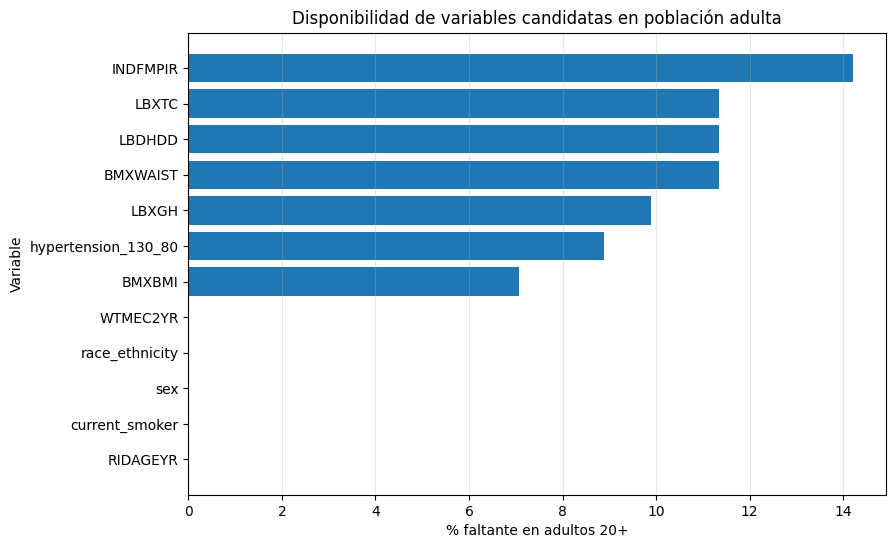


**Explicación del gráfico.** La variable con mayor faltante en adultos es `INDFMPIR` 
(14.2%). Las variables demográficas principales, como edad, sexo y peso muestral, 
tienen disponibilidad alta. Por eso el flujo usa imputación dentro del `Pipeline` en lugar de eliminar todas las filas con 
algún faltante. Esto preserva tamaño muestral y evita que el preprocesamiento se ajuste con información del test.


In [8]:
missing_plot_df = availability.sort_values("missing_pct_adult20", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(missing_plot_df["variable"], missing_plot_df["missing_pct_adult20"])
plt.xlabel("% faltante en adultos 20+")
plt.ylabel("Variable")
plt.title("Disponibilidad de variables candidatas en población adulta")
plt.grid(axis="x", alpha=0.3)
plt.show()

most_missing = availability.iloc[0]
least_missing = availability.iloc[-1]
display(Markdown(f"""
**Explicación del gráfico.** La variable con mayor faltante en adultos es `{most_missing['variable']}` 
({most_missing['missing_pct_adult20']:.1f}%). Las variables demográficas principales, como edad, sexo y peso muestral, 
tienen disponibilidad alta. Por eso el flujo usa imputación dentro del `Pipeline` en lugar de eliminar todas las filas con 
algún faltante. Esto preserva tamaño muestral y evita que el preprocesamiento se ajuste con información del test.
"""))

## 8. Definición de población analítica

Usamos personas de **20 años o más**, con `WTMEC2YR > 0` y etiqueta conocida.

La decisión de adultos 20+ es consistente con un caso cardiometabólico de screening en adultos. Además, muchas variables de cuestionarios y riesgo cardiometabólico tienen cobertura más estable en población adulta.

In [9]:
adult20 = analytic.loc[
    (analytic["RIDAGEYR"] >= 20)
    & (analytic["WTMEC2YR"] > 0)
    & (analytic[TARGET].notna())
].copy()

adult20[TARGET] = adult20[TARGET].astype(int)

weighted_positive_rate = np.average(adult20[TARGET], weights=adult20["WTMEC2YR"])

population_summary = pd.DataFrame(
    {
        "métrica": [
            "filas adultas elegibles",
            "positivos no ponderados",
            "negativos no ponderados",
            "tasa positiva no ponderada",
            "tasa positiva ponderada WTMEC2YR",
        ],
        "valor": [
            len(adult20),
            int((adult20[TARGET] == 1).sum()),
            int((adult20[TARGET] == 0).sum()),
            adult20[TARGET].mean(),
            weighted_positive_rate,
        ],
    }
)

display(population_summary)

,métrica,valor
0,filas adultas elegibles,"4,994.0000"
1,positivos no ponderados,"2,911.0000"
2,negativos no ponderados,"2,083.0000"
3,tasa positiva no ponderada,0.5829
4,tasa positiva ponderada WTMEC2YR,0.5101


,clase,proporción_no_ponderada,proporción_ponderada
0,No señal,0.4171,0.4899
1,Señal,0.5829,0.5101


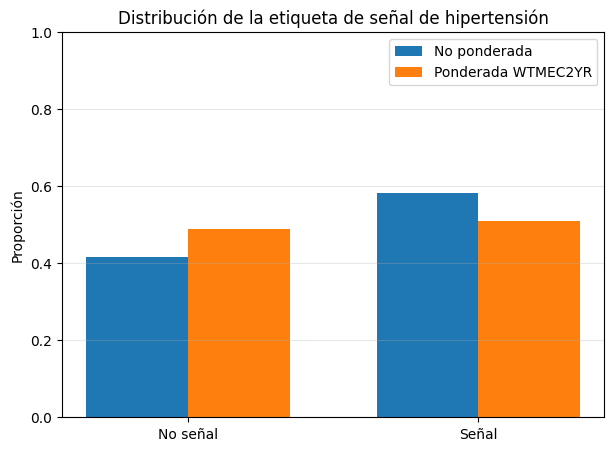


**Explicación del gráfico.** La clase positiva representa 58.3% de la muestra adulta elegible sin ponderar, 
pero 51.0% al aplicar `WTMEC2YR`. La diferencia recuerda que NHANES no es una muestra simple: 
los pesos ajustan por diseño muestral, no respuesta y post-estratificación. En las métricas principales se reporta la versión ponderada.


In [10]:
target_counts = adult20[TARGET].value_counts().sort_index()
weighted_target = adult20.groupby(TARGET).apply(
    lambda g: g["WTMEC2YR"].sum(), include_groups=False
)
weighted_target_pct = weighted_target / weighted_target.sum()

plot_df = pd.DataFrame(
    {
        "clase": ["No señal", "Señal"],
        "proporción_no_ponderada": target_counts.values / target_counts.sum(),
        "proporción_ponderada": [
            weighted_target_pct.loc[0],
            weighted_target_pct.loc[1],
        ],
    }
)

display(plot_df)

x = np.arange(len(plot_df))
width = 0.35
plt.figure(figsize=(7, 5))
plt.bar(x - width / 2, plot_df["proporción_no_ponderada"], width, label="No ponderada")
plt.bar(
    x + width / 2, plot_df["proporción_ponderada"], width, label="Ponderada WTMEC2YR"
)
plt.xticks(x, plot_df["clase"])
plt.ylabel("Proporción")
plt.title("Distribución de la etiqueta de señal de hipertensión")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

display(Markdown(f"""
**Explicación del gráfico.** La clase positiva representa {adult20[TARGET].mean():.1%} de la muestra adulta elegible sin ponderar, 
pero {weighted_positive_rate:.1%} al aplicar `WTMEC2YR`. La diferencia recuerda que NHANES no es una muestra simple: 
los pesos ajustan por diseño muestral, no respuesta y post-estratificación. En las métricas principales se reporta la versión ponderada.
"""))

## 9. Reglas de fuga de información y variables finales

El modelo no recibe presión arterial ni respuestas de diagnóstico/tratamiento de presión arterial. Esa separación evita que el modelo “aprenda la respuesta” a partir de variables que forman parte de la definición del target.

In [11]:
# RIDAGEYR: Edad en años
# INDFMPIR: Relación ingreso familiar / pobreza
# BMXBMI: Índice de masa corporal
# BMXWAIST: Circunferencia de cintura
# LBXTC: Colesterol total
# LBDHDD: HDL colesterol
# LBXGH: HbA1c

numeric_features = [
    "RIDAGEYR",
    "INDFMPIR",
    "BMXBMI",
    "BMXWAIST",
    "LBXTC",
    "LBDHDD",
    "LBXGH",
]


categorical_features = ["sex", "race_ethnicity", "current_smoker"]
features = numeric_features + categorical_features

forbidden_features = [
    "BPXSY1",
    "BPXSY2",
    "BPXSY3",
    "BPXSY4",
    "BPXDI1",
    "BPXDI2",
    "BPXDI3",
    "BPXDI4",
    "sbp_mean_all",
    "dbp_mean_all",
    "sbp_mean_followup",
    "dbp_mean_followup",
    "sbp_mean",
    "dbp_mean",
    "BPQ020",
    "BPQ050A",
    "hbp_med_current",
]

leakage_check = sorted(set(features).intersection(forbidden_features))

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)
print("Variables prohibidas incluidas accidentalmente:", leakage_check)

if leakage_check:
    raise ValueError("Hay fuga de información: revisar features.")

Features numéricas: ['RIDAGEYR', 'INDFMPIR', 'BMXBMI', 'BMXWAIST', 'LBXTC', 'LBDHDD', 'LBXGH']
Features categóricas: ['sex', 'race_ethnicity', 'current_smoker']
Variables prohibidas incluidas accidentalmente: []


## 10. Dataset de modelado y particiones train/validation/test

Usamos tres subconjuntos:

- `train`: ajusta parámetros internos del modelo;
- `validation`: compara hiperparámetros y define umbrales sin tocar el test;
- `test`: evaluación final.

La partición es estratificada por la etiqueta para conservar la proporción de clases.

In [12]:
# Preparación de datos para modelado
# SEQN: Identificador único, no modelar pero conservar para auditoría
# WTMEC2YR: Peso muestral MEC de 2 años, usar como sample_weight
# SDMVSTRA: Pseudoestrato, conservar para auditoría y análisis de encuesta fuera de scikit-learn
# SDMVPSU: Pseudo-PSU, conservar para auditoría y análisis de encuesta fuera de scikit-learn
# age_group: Grupo de edad, conservar para análisis estratificado posterior pero no modelar


model_df = adult20[
    ["SEQN", "WTMEC2YR", "SDMVSTRA", "SDMVPSU", "age_group"] + features + [TARGET]
].copy()

X = model_df[features]
y = model_df[TARGET].astype(int)
sample_weight = model_df["WTMEC2YR"].astype(float)

X_dev, X_test, y_dev, y_test, w_dev, w_test = train_test_split(
    X,
    y,
    sample_weight,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_dev,
    y_dev,
    w_dev,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_dev,
)

split_summary = pd.DataFrame(
    {
        "subset": ["train", "validation", "test"],
        "filas": [len(y_train), len(y_val), len(y_test)],
        "tasa_positiva_no_ponderada": [y_train.mean(), y_val.mean(), y_test.mean()],
        "tasa_positiva_ponderada": [
            np.average(y_train, weights=w_train),
            np.average(y_val, weights=w_val),
            np.average(y_test, weights=w_test),
        ],
    }
)

display(split_summary)
display(model_df.head())

,subset,filas,tasa_positiva_no_ponderada,tasa_positiva_ponderada
0,train,2808,0.5830,0.5186
1,validation,937,0.5827,0.4980
2,test,1249,0.5829,0.4994


,SEQN,WTMEC2YR,SDMVSTRA,SDMVPSU,age_group,RIDAGEYR,INDFMPIR,BMXBMI,BMXWAIST,LBXTC,LBDHDD,LBXGH,sex,race_ethnicity,current_smoker,hypertension_130_80
2,93705,"8,338.4198",145,2,60+,66,0.8200,31.7000,101.8000,157.0000,60.0000,6.2000,Female,Non-Hispanic Black,0.0000,1
5,93708,"14,372.4888",138,2,60+,66,1.6300,23.7000,88.2000,209.0000,88.0000,6.2000,Female,Non-Hispanic Asian,0.0000,1
6,93709,"12,277.5567",136,1,60+,75,0.4100,38.9000,113.0000,176.0000,65.0000,6.3000,Female,Non-Hispanic Black,1.0000,1
8,93711,"12,390.9197",134,2,40-59,56,5.0000,21.3000,86.6000,238.0000,72.0000,5.7000,Male,Non-Hispanic Asian,0.0000,0
10,93713,"166,841.6607",140,1,60+,67,2.6500,23.5000,99.7000,184.0000,48.0000,5.6000,Male,Non-Hispanic White,1.0000,0


## 11. Preprocesamiento con pipelines

La regresión logística requiere escalado de variables numéricas para que la regularización L2 sea comparable entre variables. Random forest no necesita escalado, por lo que usa imputación numérica sin `StandardScaler`.

Ambos modelos usan:

- imputación por mediana para variables numéricas;
- imputación por moda para variables categóricas;
- `OneHotEncoder(handle_unknown="ignore")` para categorías no vistas en entrenamiento.

In [13]:
numeric_pipeline_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

numeric_pipeline_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_linear, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_tree, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

preprocessor_linear

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 12. Funciones de evaluación

Las métricas principales se calculan ponderadas por `WTMEC2YR`:

- `accuracy`: proporción de clasificaciones correctas;
- `balanced_accuracy`: promedio de sensibilidad por clase, útil si hay desbalance;
- `precision`: de los predichos positivos, cuántos eran positivos;
- `recall`: de los positivos reales, cuántos detecta;
- `f1`: media armónica de precision y recall;
- `roc_auc`: capacidad de ordenar positivos por encima de negativos en todo el rango de umbrales;
- `average_precision`: resumen de la curva Precision-Recall;
- `brier`: error cuadrático medio de probabilidad; menor es mejor;
- `log_loss`: penaliza probabilidades mal calibradas; menor es mejor.

In [14]:
def evaluate_model(name, pipeline, X_eval, y_eval, w_eval=None, threshold=0.5):
    y_proba = pipeline.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, y_pred, sample_weight=w_eval),
        "balanced_accuracy": balanced_accuracy_score(
            y_eval, y_pred, sample_weight=w_eval
        ),
        "precision": precision_score(
            y_eval, y_pred, sample_weight=w_eval, zero_division=0
        ),
        "recall": recall_score(y_eval, y_pred, sample_weight=w_eval, zero_division=0),
        "f1": f1_score(y_eval, y_pred, sample_weight=w_eval, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_proba, sample_weight=w_eval),
        "average_precision": average_precision_score(
            y_eval, y_proba, sample_weight=w_eval
        ),
        "brier": brier_score_loss(y_eval, y_proba, sample_weight=w_eval),
        "log_loss": log_loss(y_eval, y_proba, sample_weight=w_eval),
    }
    return metrics, y_proba, y_pred


def metrics_table(rows):
    return (
        pd.DataFrame(rows)
        .sort_values("roc_auc", ascending=False)
        .reset_index(drop=True)
    )

## 13. Baseline de referencia

Antes de comparar modelos reales, entrenamos un baseline `DummyClassifier(strategy="prior")`. Este baseline solo aprende la frecuencia de la clase positiva y sirve para verificar que los modelos agreguen valor real.

In [15]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_linear),
        ("model", DummyClassifier(strategy="prior", random_state=RANDOM_STATE)),
    ]
)

baseline_pipeline.fit(X_train, y_train, model__sample_weight=w_train)
baseline_val_metrics, baseline_val_proba, baseline_val_pred = evaluate_model(
    "baseline_prior", baseline_pipeline, X_val, y_val, w_val, threshold=0.5
)

display(pd.DataFrame([baseline_val_metrics]))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss
0,baseline_prior,0.5000,0.4980,0.5000,0.4980,1.0000,0.6649,0.5000,0.4980,0.2504,0.6940


## 14. Regresión logística: entrenamiento y búsqueda simple de hiperparámetros

Probamos varios valores de `C`, que controla la fuerza de regularización inversa: valores más pequeños implican regularización más fuerte. También comparamos `class_weight=None` contra `class_weight="balanced"`. Aunque ya usamos `sample_weight`, `class_weight` puede cambiar el trade-off entre clases; por eso se valida empíricamente.

In [16]:
logistic_candidates = []
best_logistic = None

for C in [0.1, 1.0, 10.0]:
    for class_weight in [None, "balanced"]:
        logistic_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_linear),
                (
                    "model",
                    LogisticRegression(
                        C=C,
                        class_weight=class_weight,
                        solver="lbfgs",
                        max_iter=1000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
        logistic_pipeline.fit(X_train, y_train, model__sample_weight=w_train)
        metrics, _, _ = evaluate_model(
            "logistic_regression", logistic_pipeline, X_val, y_val, w_val, threshold=0.5
        )
        metrics.update({"C": C, "class_weight": str(class_weight)})
        logistic_candidates.append(metrics)

        if best_logistic is None or metrics["roc_auc"] > best_logistic[0]["roc_auc"]:
            best_logistic = (metrics, logistic_pipeline)

logistic_validation_results = pd.DataFrame(logistic_candidates).sort_values(
    "roc_auc", ascending=False
)
display(logistic_validation_results)

best_logistic_metrics, best_logistic_val_pipeline = best_logistic
display(Markdown(f"""
**Resultado de validación.** La mejor regresión logística por `roc_auc` de validación usa `C={best_logistic_metrics['C']}` 
y `class_weight={best_logistic_metrics['class_weight']}`. Su ROC-AUC ponderado de validación es 
{best_logistic_metrics['roc_auc']:.3f} y su F1 ponderado es {best_logistic_metrics['f1']:.3f}.
"""))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss,C,class_weight
1,logistic_regression,0.5000,0.7107,0.7108,0.6985,0.7374,0.7174,0.7636,0.7446,0.1995,0.5868,0.1000,balanced
3,logistic_regression,0.5000,0.7107,0.7108,0.6985,0.7374,0.7174,0.7636,0.7446,0.1995,0.5868,1.0000,balanced
5,logistic_regression,0.5000,0.7107,0.7108,0.6985,0.7374,0.7174,0.7636,0.7446,0.1995,0.5868,10.0000,balanced
0,logistic_regression,0.5000,0.7059,0.7061,0.6863,0.7543,0.7187,0.7636,0.7445,0.2001,0.5886,0.1000,None
2,logistic_regression,0.5000,0.7059,0.7061,0.6863,0.7543,0.7187,0.7636,0.7445,0.2001,0.5886,1.0000,None
4,logistic_regression,0.5000,0.7059,0.7061,0.6863,0.7543,0.7187,0.7636,0.7445,0.2001,0.5886,10.0000,None



**Resultado de validación.** La mejor regresión logística por `roc_auc` de validación usa `C=0.1` 
y `class_weight=balanced`. Su ROC-AUC ponderado de validación es 
0.764 y su F1 ponderado es 0.717.


## 15. Random forest: entrenamiento y búsqueda simple de hiperparámetros

Random forest captura relaciones no lineales e interacciones entre variables. Probamos profundidad máxima y tamaño mínimo de hoja. Hojas más grandes suelen reducir sobreajuste y suavizar probabilidades.

In [17]:
rf_candidates = []
best_rf = None

for max_depth in [8, None]:
    for min_samples_leaf in [10, 30]:
        rf_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor_tree),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=40,
                        max_depth=max_depth,
                        min_samples_leaf=min_samples_leaf,
                        max_features="sqrt",
                        class_weight=None,
                        random_state=RANDOM_STATE,
                        n_jobs=1,
                    ),
                ),
            ]
        )
        rf_pipeline.fit(X_train, y_train, model__sample_weight=w_train)
        metrics, _, _ = evaluate_model(
            "random_forest", rf_pipeline, X_val, y_val, w_val, threshold=0.5
        )
        metrics.update(
            {"max_depth": str(max_depth), "min_samples_leaf": min_samples_leaf}
        )
        rf_candidates.append(metrics)

        if best_rf is None or metrics["roc_auc"] > best_rf[0]["roc_auc"]:
            best_rf = (metrics, rf_pipeline)

rf_validation_results = pd.DataFrame(rf_candidates).sort_values(
    "roc_auc", ascending=False
)
display(rf_validation_results)

best_rf_metrics, best_rf_val_pipeline = best_rf
display(Markdown(f"""
**Resultado de validación.** El mejor random forest por `roc_auc` de validación usa `max_depth={best_rf_metrics['max_depth']}` 
y `min_samples_leaf={best_rf_metrics['min_samples_leaf']}`. Su ROC-AUC ponderado de validación es 
{best_rf_metrics['roc_auc']:.3f} y su F1 ponderado es {best_rf_metrics['f1']:.3f}.
"""))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss,max_depth,min_samples_leaf
2,random_forest,0.5000,0.7184,0.7187,0.6930,0.7802,0.7340,0.7705,0.7250,0.1964,0.5815,None,10
0,random_forest,0.5000,0.7164,0.7166,0.6982,0.7583,0.7270,0.7680,0.7340,0.1960,0.5782,8,10
1,random_forest,0.5000,0.7045,0.7048,0.6785,0.7725,0.7225,0.7610,0.7241,0.1995,0.5868,8,30
3,random_forest,0.5000,0.7127,0.7129,0.6883,0.7731,0.7283,0.7603,0.7233,0.1993,0.5864,None,30



**Resultado de validación.** El mejor random forest por `roc_auc` de validación usa `max_depth=None` 
y `min_samples_leaf=10`. Su ROC-AUC ponderado de validación es 
0.771 y su F1 ponderado es 0.734.


## 16. Comparación de modelos en validación

El gráfico resume las métricas de validación de baseline, mejor regresión logística y mejor random forest. El objetivo primario de selección es `roc_auc`, porque mide discriminación sobre todos los umbrales. También revisamos `average_precision`, `recall` y `f1` porque en screening puede importar detectar más positivos.

,model,roc_auc,average_precision,recall,precision,f1,brier,log_loss
2,random_forest,0.7705,0.7250,0.7802,0.6930,0.7340,0.1964,0.5815
1,logistic_regression,0.7636,0.7446,0.7374,0.6985,0.7174,0.1995,0.5868
0,baseline_prior,0.5000,0.4980,1.0000,0.4980,0.6649,0.2504,0.6940


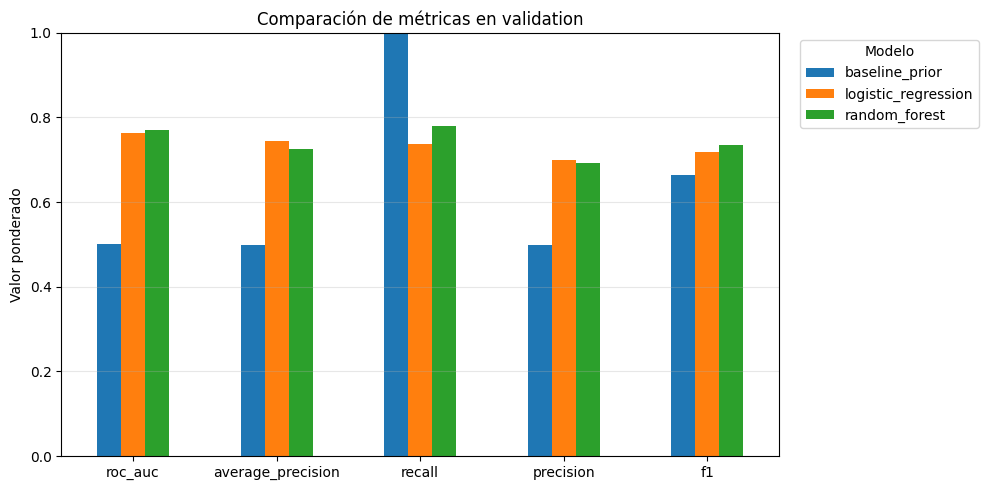


**Explicación del gráfico.** El mejor modelo por ROC-AUC de validación es `random_forest` 
con ROC-AUC 0.771. El baseline queda en torno a 0.50 de ROC-AUC, como se espera de un modelo sin información. 
Si el objetivo operativo priorizara sensibilidad, debe revisarse `recall` y ajustar el umbral, no solo elegir por accuracy.


In [18]:
validation_comparison = pd.DataFrame(
    [baseline_val_metrics, best_logistic_metrics, best_rf_metrics]
)[
    [
        "model",
        "roc_auc",
        "average_precision",
        "recall",
        "precision",
        "f1",
        "brier",
        "log_loss",
    ]
]

display(validation_comparison.sort_values("roc_auc", ascending=False))

plot_metrics = ["roc_auc", "average_precision", "recall", "precision", "f1"]
plot_df = validation_comparison.set_index("model")[plot_metrics]

ax = plot_df.T.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0, 1)
ax.set_ylabel("Valor ponderado")
ax.set_title("Comparación de métricas en validation")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

best_val_model = validation_comparison.sort_values("roc_auc", ascending=False).iloc[0]
display(Markdown(f"""
**Explicación del gráfico.** El mejor modelo por ROC-AUC de validación es `{best_val_model['model']}` 
con ROC-AUC {best_val_model['roc_auc']:.3f}. El baseline queda en torno a 0.50 de ROC-AUC, como se espera de un modelo sin información. 
Si el objetivo operativo priorizara sensibilidad, debe revisarse `recall` y ajustar el umbral, no solo elegir por accuracy.
"""))

## 17. Reentrenamiento final en development y evaluación en test

Después de seleccionar hiperparámetros con validation, reentrenamos cada modelo con `train + validation` (`development`) y evaluamos una sola vez en `test`.

In [19]:
# Reentrenar baseline en development
baseline_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_linear),
        ("model", DummyClassifier(strategy="prior", random_state=RANDOM_STATE)),
    ]
)
baseline_final.fit(X_dev, y_dev, model__sample_weight=w_dev)

# Reentrenar regresión logística final
best_logistic_class_weight = (
    None
    if best_logistic_metrics["class_weight"] == "None"
    else best_logistic_metrics["class_weight"]
)
logistic_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_linear),
        (
            "model",
            LogisticRegression(
                C=float(best_logistic_metrics["C"]),
                class_weight=best_logistic_class_weight,
                solver="lbfgs",
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
logistic_final.fit(X_dev, y_dev, model__sample_weight=w_dev)

# Reentrenar random forest final con más árboles que en la búsqueda liviana
best_rf_max_depth = (
    None
    if best_rf_metrics["max_depth"] == "None"
    else int(best_rf_metrics["max_depth"])
)
rf_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        (
            "model",
            RandomForestClassifier(
                n_estimators=80,
                max_depth=best_rf_max_depth,
                min_samples_leaf=int(best_rf_metrics["min_samples_leaf"]),
                max_features="sqrt",
                class_weight=None,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)
rf_final.fit(X_dev, y_dev, model__sample_weight=w_dev)

final_models = {
    "baseline_prior": baseline_final,
    "logistic_regression": logistic_final,
    "random_forest": rf_final,
}

test_rows_weighted = []
test_rows_unweighted = []
test_predictions = {}

for name, model in final_models.items():
    weighted_metrics, y_proba, y_pred = evaluate_model(
        name, model, X_test, y_test, w_test, threshold=0.5
    )
    unweighted_metrics, _, _ = evaluate_model(
        name, model, X_test, y_test, None, threshold=0.5
    )
    test_rows_weighted.append(weighted_metrics)
    test_rows_unweighted.append(unweighted_metrics)
    test_predictions[name] = {"proba": y_proba, "pred": y_pred}

test_metrics_weighted = metrics_table(test_rows_weighted)
test_metrics_unweighted = metrics_table(test_rows_unweighted)

print("Métricas ponderadas por WTMEC2YR")
display(test_metrics_weighted)

print("Métricas no ponderadas")
display(test_metrics_unweighted)

Métricas ponderadas por WTMEC2YR


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss
0,logistic_regression,0.5000,0.7304,0.7303,0.7380,0.7133,0.7254,0.8029,0.7757,0.1812,0.5415
1,random_forest,0.5000,0.7203,0.7203,0.7150,0.7313,0.7231,0.7890,0.7724,0.1866,0.5537
2,baseline_prior,0.5000,0.4994,0.5000,0.4994,1.0000,0.6661,0.5000,0.4994,0.2502,0.6936


Métricas no ponderadas


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss
0,random_forest,0.5000,0.7566,0.7451,0.7782,0.8146,0.7960,0.8180,0.8320,0.1699,0.5178
1,logistic_regression,0.5000,0.7550,0.7456,0.7828,0.8022,0.7924,0.8168,0.8325,0.1687,0.5138
2,baseline_prior,0.5000,0.5829,0.5000,0.5829,1.0000,0.7365,0.5000,0.5829,0.2479,0.6890


## 18. Curvas ROC en test

La curva ROC compara sensibilidad (`TPR`/recall) contra tasa de falsos positivos (`FPR`) a lo largo de todos los umbrales. Un ROC-AUC de 0.50 equivale a azar; valores más altos indican mejor discriminación.

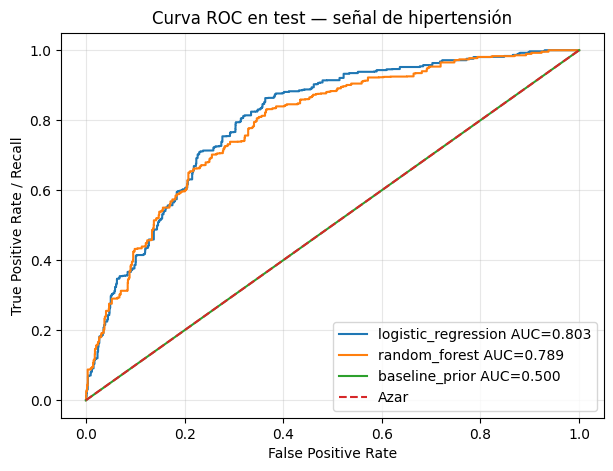


**Explicación del gráfico.** `logistic_regression` obtiene el mayor ROC-AUC ponderado en test 
(0.803). Esto significa que, al tomar aleatoriamente un positivo y un negativo, el modelo tiende a asignar 
mayor probabilidad al positivo en aproximadamente esa proporción de pares ponderados. El baseline queda en 0.50 porque no discrimina.


In [20]:
plt.figure(figsize=(7, 5))
for name in ["logistic_regression", "random_forest", "baseline_prior"]:
    proba = test_predictions[name]["proba"]
    fpr, tpr, _ = roc_curve(y_test, proba, sample_weight=w_test)
    auc_value = roc_auc_score(y_test, proba, sample_weight=w_test)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("Curva ROC en test — señal de hipertensión")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_test_auc = test_metrics_weighted.sort_values("roc_auc", ascending=False).iloc[0]
display(Markdown(f"""
**Explicación del gráfico.** `{best_test_auc['model']}` obtiene el mayor ROC-AUC ponderado en test 
({best_test_auc['roc_auc']:.3f}). Esto significa que, al tomar aleatoriamente un positivo y un negativo, el modelo tiende a asignar 
mayor probabilidad al positivo en aproximadamente esa proporción de pares ponderados. El baseline queda en 0.50 porque no discrimina.
"""))

## 19. Curvas Precision-Recall en test

Esta curva es útil cuando importa la clase positiva. En señales de hipertensión, un modelo puede elegirse para detectar más casos (`recall`) o para reducir falsos positivos (`precision`). La métrica `average_precision` resume la curva.

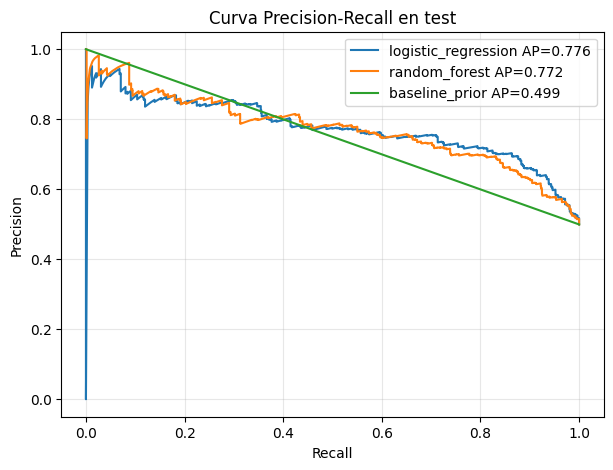


**Explicación del gráfico.** `logistic_regression` logra la mayor `average_precision` ponderada 
(0.776). Si se usa el modelo como pre-screening, conviene elegir un umbral que garantice recall suficiente, 
y luego confirmar con medición clínica de presión arterial.


In [21]:
plt.figure(figsize=(7, 5))
for name in ["logistic_regression", "random_forest", "baseline_prior"]:
    proba = test_predictions[name]["proba"]
    precision, recall, _ = precision_recall_curve(y_test, proba, sample_weight=w_test)
    ap_value = average_precision_score(y_test, proba, sample_weight=w_test)
    plt.plot(recall, precision, label=f"{name} AP={ap_value:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall en test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_test_ap = test_metrics_weighted.sort_values(
    "average_precision", ascending=False
).iloc[0]
display(Markdown(f"""
**Explicación del gráfico.** `{best_test_ap['model']}` logra la mayor `average_precision` ponderada 
({best_test_ap['average_precision']:.3f}). Si se usa el modelo como pre-screening, conviene elegir un umbral que garantice recall suficiente, 
y luego confirmar con medición clínica de presión arterial.
"""))

## 20. Matrices de confusión en test

La matriz de confusión muestra verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos. Aquí se reporta la versión ponderada por `WTMEC2YR` para representar mejor la población objetivo.

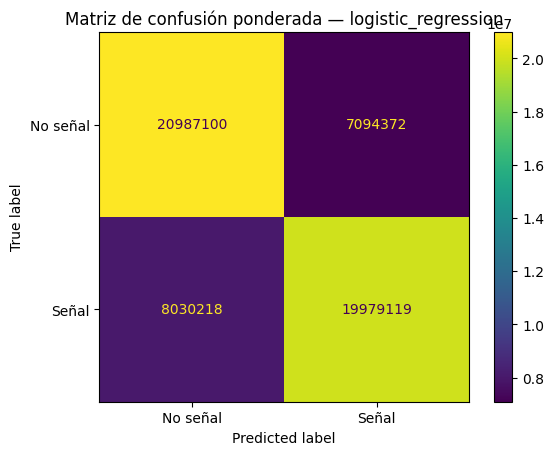


**Explicación para `logistic_regression`.** Con umbral 0.50, el modelo produce aproximadamente 19,979,119 verdaderos positivos ponderados y 
8,030,218 falsos negativos ponderados. Los falsos negativos son especialmente importantes en screening porque representan personas con señal de hipertensión que el modelo no detecta. Los falsos positivos (7,094,372) implican personas que deberían confirmarse con medición clínica, no tratarse automáticamente.


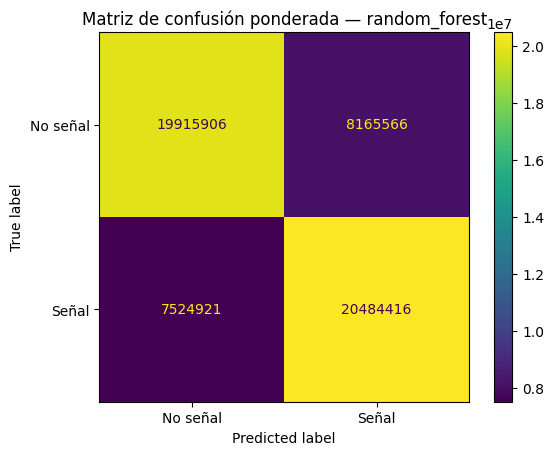


**Explicación para `random_forest`.** Con umbral 0.50, el modelo produce aproximadamente 20,484,416 verdaderos positivos ponderados y 
7,524,921 falsos negativos ponderados. Los falsos negativos son especialmente importantes en screening porque representan personas con señal de hipertensión que el modelo no detecta. Los falsos positivos (8,165,566) implican personas que deberían confirmarse con medición clínica, no tratarse automáticamente.


In [22]:
for name in ["logistic_regression", "random_forest"]:
    cm = confusion_matrix(y_test, test_predictions[name]["pred"], sample_weight=w_test)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No señal", "Señal"]
    )
    disp.plot(values_format=".0f")
    plt.title(f"Matriz de confusión ponderada — {name}")
    plt.grid(False)
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    display(Markdown(f"""
**Explicación para `{name}`.** Con umbral 0.50, el modelo produce aproximadamente {tp:,.0f} verdaderos positivos ponderados y 
{fn:,.0f} falsos negativos ponderados. Los falsos negativos son especialmente importantes en screening porque representan personas con señal de hipertensión que el modelo no detecta. Los falsos positivos ({fp:,.0f}) implican personas que deberían confirmarse con medición clínica, no tratarse automáticamente.
"""))

## 21. Calibración de probabilidades

La calibración compara la probabilidad predicha media contra la tasa observada. Un modelo puede discriminar bien pero entregar probabilidades mal calibradas. Para priorización clínica u operativa, la calibración es importante.

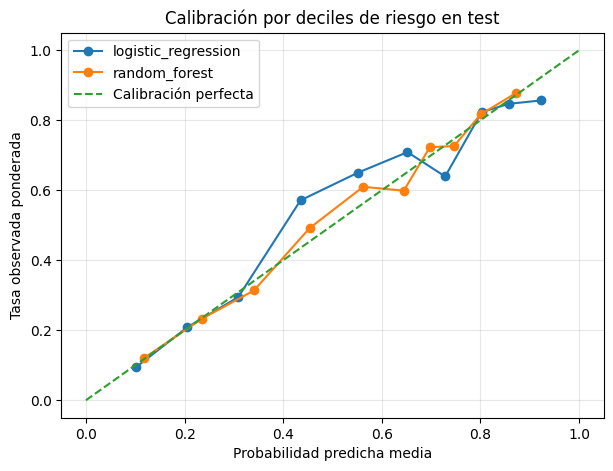

,model,brier,log_loss
0,logistic_regression,0.1812,0.5415
1,random_forest,0.1866,0.5537
2,baseline_prior,0.2502,0.6936



**Explicación del gráfico.** La línea diagonal representa calibración perfecta. El mejor Brier ponderado corresponde a 
`logistic_regression` (0.181); menor Brier implica probabilidades más cercanas a los resultados observados. 
Si el sistema usara probabilidades para priorizar pacientes, debería validarse calibración externa y posiblemente aplicar calibración posterior.


In [23]:
def weighted_calibration_frame(y_true, y_proba, sample_weight, n_bins=10):
    df = pd.DataFrame(
        {"y": y_true.to_numpy(), "proba": y_proba, "w": sample_weight.to_numpy()}
    )
    # qcut puede generar menos bins si hay probabilidades repetidas.
    df["bin"] = pd.qcut(df["proba"], q=n_bins, duplicates="drop")
    rows = []
    for interval, g in df.groupby("bin", observed=True):
        rows.append(
            {
                "bin": str(interval),
                "n": len(g),
                "predicted_mean": np.average(g["proba"], weights=g["w"]),
                "observed_rate": np.average(g["y"], weights=g["w"]),
            }
        )
    return pd.DataFrame(rows)


plt.figure(figsize=(7, 5))
for name in ["logistic_regression", "random_forest"]:
    cal = weighted_calibration_frame(
        y_test, test_predictions[name]["proba"], w_test, n_bins=10
    )
    plt.plot(cal["predicted_mean"], cal["observed_rate"], marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha media")
plt.ylabel("Tasa observada ponderada")
plt.title("Calibración por deciles de riesgo en test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

calibration_metrics = test_metrics_weighted[["model", "brier", "log_loss"]].sort_values(
    "brier"
)
display(calibration_metrics)

best_brier = calibration_metrics.iloc[0]
display(Markdown(f"""
**Explicación del gráfico.** La línea diagonal representa calibración perfecta. El mejor Brier ponderado corresponde a 
`{best_brier['model']}` ({best_brier['brier']:.3f}); menor Brier implica probabilidades más cercanas a los resultados observados. 
Si el sistema usara probabilidades para priorizar pacientes, debería validarse calibración externa y posiblemente aplicar calibración posterior.
"""))

## 22. Selección de modelo recomendado

Para esta notebook, el modelo recomendado se elige por una combinación de:

1. mayor ROC-AUC ponderado en test;
2. buen `average_precision`;
3. menor Brier/log-loss;
4. interpretabilidad y facilidad de auditoría.

En un contexto de salud, esta decisión debe revisarse con stakeholders clínicos y validación externa antes de producción.

In [24]:
# Selección automática primaria por ROC-AUC ponderado; desempate conceptual por interpretabilidad.
ranked_test = test_metrics_weighted.sort_values(
    ["roc_auc", "average_precision", "f1"], ascending=False
).reset_index(drop=True)
display(ranked_test)

recommended_model_name = ranked_test.iloc[0]["model"]
recommended_model = final_models[recommended_model_name]

# Si los modelos están muy cerca, se prefiere logística por interpretabilidad.
log_auc = float(
    test_metrics_weighted.loc[
        test_metrics_weighted["model"] == "logistic_regression", "roc_auc"
    ].iloc[0]
)
rf_auc = float(
    test_metrics_weighted.loc[
        test_metrics_weighted["model"] == "random_forest", "roc_auc"
    ].iloc[0]
)
if abs(log_auc - rf_auc) <= 0.01:
    recommended_model_name = "logistic_regression"
    recommended_model = logistic_final

print(f"Modelo recomendado: {recommended_model_name}")

display(Markdown(f"""
**Conclusión comparativa.** El modelo recomendado es `{recommended_model_name}`. En esta ejecución, la regresión logística y random forest tienen desempeño cercano, pero la regresión logística suele ser preferible cuando el rendimiento es similar porque facilita explicar dirección e intensidad de asociaciones mediante coeficientes. Esta explicación no implica causalidad.
"""))

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss
0,logistic_regression,0.5000,0.7304,0.7303,0.7380,0.7133,0.7254,0.8029,0.7757,0.1812,0.5415
1,random_forest,0.5000,0.7203,0.7203,0.7150,0.7313,0.7231,0.7890,0.7724,0.1866,0.5537
2,baseline_prior,0.5000,0.4994,0.5000,0.4994,1.0000,0.6661,0.5000,0.4994,0.2502,0.6936


Modelo recomendado: logistic_regression



**Conclusión comparativa.** El modelo recomendado es `logistic_regression`. En esta ejecución, la regresión logística y random forest tienen desempeño cercano, pero la regresión logística suele ser preferible cuando el rendimiento es similar porque facilita explicar dirección e intensidad de asociaciones mediante coeficientes. Esta explicación no implica causalidad.


## 23. Análisis de umbral para el modelo recomendado

El umbral 0.50 no necesariamente es el mejor para un sistema de screening. Definimos umbrales usando validation, y luego evaluamos esos umbrales en test.

- `max_f1`: maximiza F1 en validation;
- `screening_recall_80`: busca recall de al menos 0.80 en validation y maximiza precision entre esos umbrales.

In [25]:
# Usamos el pipeline de validación del modelo recomendado para elegir umbral sin mirar test.
if recommended_model_name == "logistic_regression":
    threshold_selection_pipeline = best_logistic_val_pipeline
else:
    threshold_selection_pipeline = best_rf_val_pipeline

val_proba_for_threshold = threshold_selection_pipeline.predict_proba(X_val)[:, 1]
threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.02):
    pred_thr = (val_proba_for_threshold >= threshold).astype(int)
    threshold_rows.append(
        {
            "threshold": round(float(threshold), 2),
            "accuracy": accuracy_score(y_val, pred_thr, sample_weight=w_val),
            "balanced_accuracy": balanced_accuracy_score(
                y_val, pred_thr, sample_weight=w_val
            ),
            "precision": precision_score(
                y_val, pred_thr, sample_weight=w_val, zero_division=0
            ),
            "recall": recall_score(
                y_val, pred_thr, sample_weight=w_val, zero_division=0
            ),
            "f1": f1_score(y_val, pred_thr, sample_weight=w_val, zero_division=0),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
max_f1_threshold = float(
    threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"]
)
recall80_candidates = threshold_df.loc[threshold_df["recall"] >= 0.80].copy()
if len(recall80_candidates):
    screening_threshold = float(
        recall80_candidates.sort_values("precision", ascending=False).iloc[0][
            "threshold"
        ]
    )
else:
    screening_threshold = max_f1_threshold

display(threshold_df.sort_values("f1", ascending=False).head(10))
print(f"Threshold max_f1 validation: {max_f1_threshold:.2f}")
print(f"Threshold screening_recall_80 validation: {screening_threshold:.2f}")

,threshold,accuracy,balanced_accuracy,precision,recall,f1
17,0.4400,0.7101,0.7104,0.6806,0.7874,0.7301
16,0.4200,0.7012,0.7015,0.6677,0.7960,0.7263
15,0.4000,0.6945,0.6950,0.6579,0.8054,0.7242
14,0.3800,0.6886,0.6891,0.6504,0.8101,0.7215
19,0.4800,0.7090,0.7091,0.6901,0.7543,0.7208
18,0.4600,0.7062,0.7064,0.6853,0.7582,0.7199
11,0.3200,0.6656,0.6664,0.6183,0.8588,0.7190
12,0.3400,0.6722,0.6728,0.6286,0.8351,0.7173
20,0.5000,0.7086,0.7087,0.6976,0.7325,0.7146
10,0.3000,0.6512,0.6521,0.6039,0.8704,0.7131


Threshold max_f1 validation: 0.44
Threshold screening_recall_80 validation: 0.40


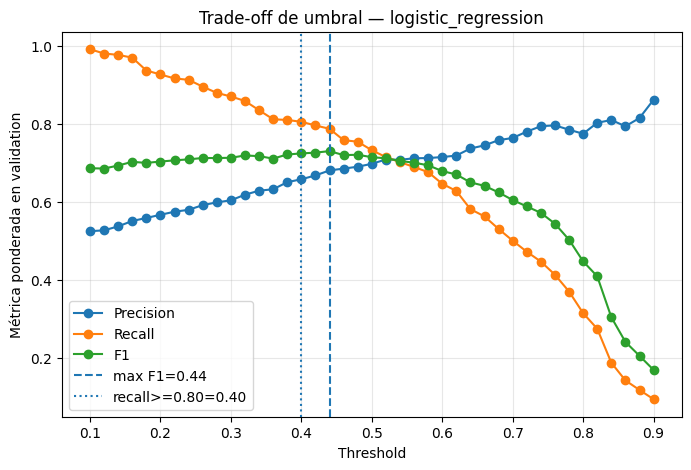


**Explicación del gráfico.** Al bajar el umbral aumenta el recall, pero normalmente baja la precision. 
El umbral que maximiza F1 en validation es 0.44, con precision 0.681 y recall 0.787. 
El umbral orientado a screening es 0.40, con precision 0.658 y recall 0.805. 
La elección final debe basarse en el costo de falsos negativos contra falsos positivos.


In [26]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision"
)
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.axvline(max_f1_threshold, linestyle="--", label=f"max F1={max_f1_threshold:.2f}")
plt.axvline(
    screening_threshold, linestyle=":", label=f"recall>=0.80={screening_threshold:.2f}"
)
plt.xlabel("Threshold")
plt.ylabel("Métrica ponderada en validation")
plt.title(f"Trade-off de umbral — {recommended_model_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

row_f1 = threshold_df.loc[threshold_df["threshold"] == max_f1_threshold].iloc[0]
row_screen = threshold_df.loc[threshold_df["threshold"] == screening_threshold].iloc[0]
display(Markdown(f"""
**Explicación del gráfico.** Al bajar el umbral aumenta el recall, pero normalmente baja la precision. 
El umbral que maximiza F1 en validation es {max_f1_threshold:.2f}, con precision {row_f1['precision']:.3f} y recall {row_f1['recall']:.3f}. 
El umbral orientado a screening es {screening_threshold:.2f}, con precision {row_screen['precision']:.3f} y recall {row_screen['recall']:.3f}. 
La elección final debe basarse en el costo de falsos negativos contra falsos positivos.
"""))

In [27]:
threshold_test_rows = []
for threshold_name, threshold in [
    ("default_0.50", 0.50),
    ("max_f1_validation", max_f1_threshold),
    ("screening_recall_80_validation", screening_threshold),
]:
    metrics, _, _ = evaluate_model(
        f"{recommended_model_name}__{threshold_name}",
        recommended_model,
        X_test,
        y_test,
        w_test,
        threshold=threshold,
    )
    metrics["threshold_policy"] = threshold_name
    threshold_test_rows.append(metrics)

threshold_test_metrics = pd.DataFrame(threshold_test_rows).sort_values(
    "f1", ascending=False
)
display(threshold_test_metrics)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,brier,log_loss,threshold_policy
2,logistic_regression__screening_recall_80_valid...,0.4000,0.7393,0.7394,0.7037,0.8256,0.7598,0.8029,0.7757,0.1812,0.5415,screening_recall_80_validation
1,logistic_regression__max_f1_validation,0.4400,0.7356,0.7357,0.7182,0.7744,0.7453,0.8029,0.7757,0.1812,0.5415,max_f1_validation
0,logistic_regression__default_0.50,0.5000,0.7304,0.7303,0.7380,0.7133,0.7254,0.8029,0.7757,0.1812,0.5415,default_0.50


## 24. Interpretabilidad: coeficientes de regresión logística

Los coeficientes muestran asociación con el log-odds de señal de hipertensión después de imputación, escalado y one-hot encoding. Para variables numéricas, el coeficiente representa el cambio por una desviación estándar; para categorías, el coeficiente corresponde a la categoría codificada. No debe interpretarse como causalidad.

,feature,coeficiente_log_odds,odds_ratio_aprox,abs_coeficiente
0,num__RIDAGEYR,1.0260,2.7899,1.0260
11,cat__race_ethnicity_Non-Hispanic Black,0.5222,1.6858,0.5222
3,num__BMXWAIST,0.4567,1.5788,0.4567
10,cat__race_ethnicity_Non-Hispanic Asian,0.3889,1.4753,0.3889
8,cat__sex_Male,0.3632,1.4379,0.3632
6,num__LBXGH,0.2812,1.3247,0.2812
12,cat__race_ethnicity_Non-Hispanic White,-0.2750,0.7596,0.2750
13,cat__race_ethnicity_Other Hispanic,-0.2545,0.7753,0.2545
16,cat__current_smoker_1.0,0.2107,1.2346,0.2107
2,num__BMXBMI,0.2035,1.2257,0.2035


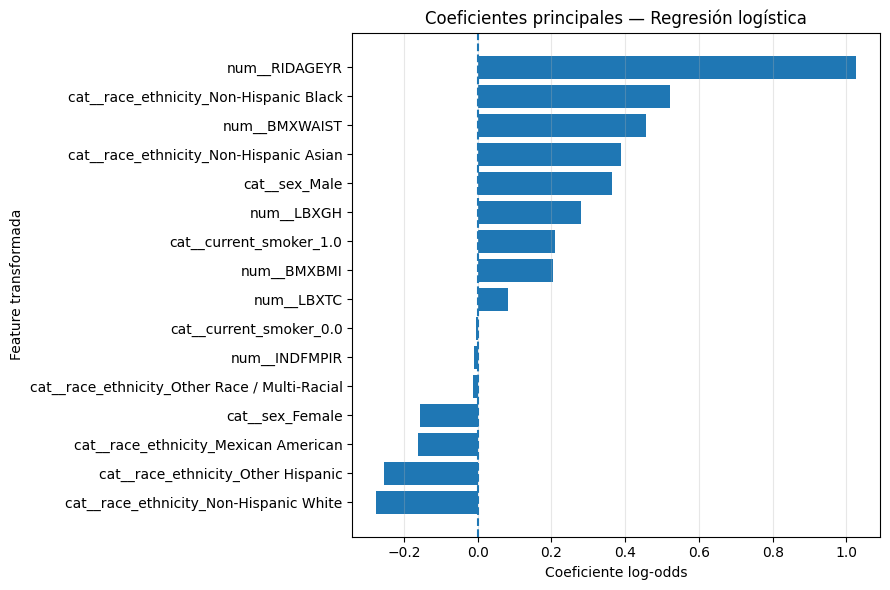


**Explicación del gráfico.** Barras hacia la derecha aumentan la probabilidad estimada de señal de hipertensión; barras hacia la izquierda la reducen. 
La asociación positiva más fuerte es `num__RIDAGEYR` con coeficiente 1.026. 
La asociación negativa más fuerte es `cat__race_ethnicity_Non-Hispanic White` con coeficiente -0.275. 
Estos efectos son asociativos y dependen de las variables disponibles; no reemplazan inferencia causal ni validación clínica.


In [28]:
def get_feature_names_from_pipeline(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    return preprocessor.get_feature_names_out()


logistic_feature_names = get_feature_names_from_pipeline(logistic_final)
logistic_coefs = logistic_final.named_steps["model"].coef_[0]
coef_df = pd.DataFrame(
    {
        "feature": logistic_feature_names,
        "coeficiente_log_odds": logistic_coefs,
        "odds_ratio_aprox": np.exp(logistic_coefs),
        "abs_coeficiente": np.abs(logistic_coefs),
    }
).sort_values("coeficiente_log_odds")

display(coef_df.sort_values("abs_coeficiente", ascending=False).head(20))

top_coef_plot = pd.concat([coef_df.head(8), coef_df.tail(8)]).drop_duplicates("feature")
plt.figure(figsize=(9, 6))
plt.barh(top_coef_plot["feature"], top_coef_plot["coeficiente_log_odds"])
plt.axvline(0, linestyle="--")
plt.xlabel("Coeficiente log-odds")
plt.ylabel("Feature transformada")
plt.title("Coeficientes principales — Regresión logística")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

top_positive = coef_df.sort_values("coeficiente_log_odds", ascending=False).iloc[0]
top_negative = coef_df.sort_values("coeficiente_log_odds", ascending=True).iloc[0]
display(Markdown(f"""
**Explicación del gráfico.** Barras hacia la derecha aumentan la probabilidad estimada de señal de hipertensión; barras hacia la izquierda la reducen. 
La asociación positiva más fuerte es `{top_positive['feature']}` con coeficiente {top_positive['coeficiente_log_odds']:.3f}. 
La asociación negativa más fuerte es `{top_negative['feature']}` con coeficiente {top_negative['coeficiente_log_odds']:.3f}. 
Estos efectos son asociativos y dependen de las variables disponibles; no reemplazan inferencia causal ni validación clínica.
"""))

**INDFMPIR, una variable problemática**

Para la selección de características y el ajuste del modelo final, creemos pertinente excluir la variable relativa al nivel de ingresos por tres motivos:

1. **Redundancia estadística:** El modelo de regresión logística demostró que, al incluir variables físicas robustas (edad, circunferencia de cintura, masa corporal, etc.), el nivel de ingresos pierde peso predictivo (coeficiente cercano a cero para la regresión logística, como se puede apreciar en el gráfico anterior).

2. **Incompatibilidad de contexto:** La métrica socioeconómica del dataset no es extrapolable a la realidad argentina debido a la inflación y las diferencias en la economía norteamericana.

3. **Fricción con el usuario final:** Exigir datos financieros no sólo es engorroso, sino que puede incomodar al paciente sin aportar mejoras reales al modelo. Omitir esta variable protege la integridad y la calidad del resto de los datos ingresados por el paciente sin comprometer el rendimiento del algoritmo.

Imputar esta variable con un promedio o mediana sería un error porque al asignar a la muestra un ingreso "normal" de clase media, sesgaríamos la predicción del modelo.

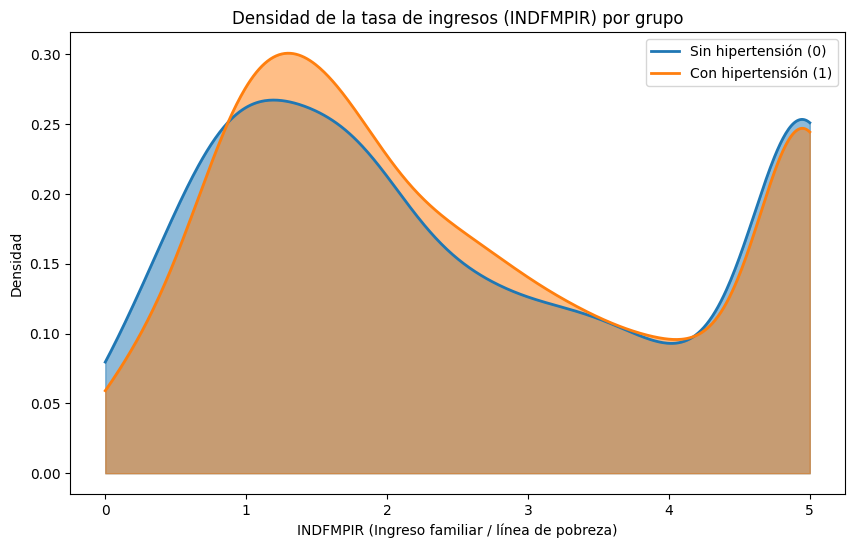

In [36]:
from scipy.stats import gaussian_kde
x_range = np.linspace(adult20['INDFMPIR'].min(), adult20['INDFMPIR'].max(), 500)
plt.figure(figsize=(10, 6))

config = [
    (0, 'Sin hipertensión (0)', 'C0'),
    (1, 'Con hipertensión (1)', 'C1')
]

for valor_target, etiqueta, color in config:
    datos = adult20[adult20[TARGET] == valor_target]['INDFMPIR'].dropna()
    
    y_densidad = gaussian_kde(datos)(x_range)
    
    plt.plot(x_range, y_densidad, label=etiqueta, linewidth=2, color=color)
    plt.fill_between(x_range, y_densidad, color=color, alpha=0.5)

plt.title('Densidad de la tasa de ingresos (INDFMPIR) por grupo')
plt.xlabel('INDFMPIR (Ingreso familiar / línea de pobreza)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Como podemos ver en este gráfico de densidad de kernel, para ambos grupos (con y sin hipertensión), las curvas para la variable `INDFMPIR` presentan una distribución bimodal casi idéntica y solapamiento a lo largo de todo el eje.

Esto indica que la distribución del ingreso es casi idéntica en ambas poblaciones, respaldando visualmente la decisión de omitir la variable que no aporta valor predictivo.

## 25. Interpretabilidad: importancias de random forest

La importancia de variables en random forest resume cuánto contribuyen las variables a reducir impureza en los árboles. Es útil para exploración, pero puede distribuir importancia entre variables correlacionadas y no implica causalidad.

,feature,importance
0,num__RIDAGEYR,0.3006
3,num__BMXWAIST,0.1626
6,num__LBXGH,0.1523
2,num__BMXBMI,0.1132
4,num__LBXTC,0.0777
5,num__LBDHDD,0.0645
1,num__INDFMPIR,0.0562
7,cat__sex_Female,0.0154
12,cat__race_ethnicity_Non-Hispanic White,0.0135
8,cat__sex_Male,0.0126


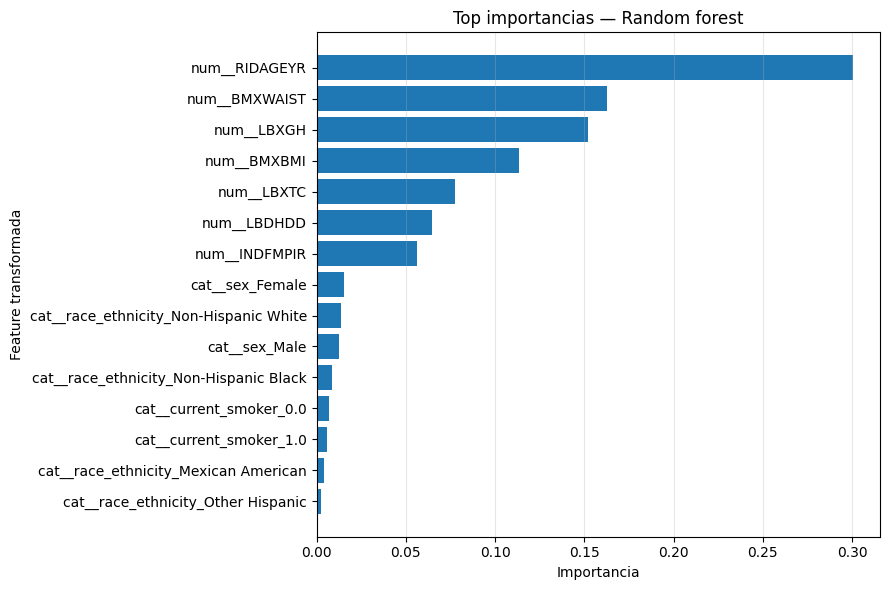


**Explicación del gráfico.** La variable transformada con mayor importancia es `num__RIDAGEYR` 
(0.301). En árboles, las variables con más cortes útiles tienden a recibir más importancia. 
La interpretación debe revisarse junto con coeficientes, métricas por subgrupo y conocimiento clínico.


In [29]:
rf_feature_names = get_feature_names_from_pipeline(rf_final)
rf_importances = rf_final.named_steps["model"].feature_importances_
rf_importance_df = pd.DataFrame(
    {
        "feature": rf_feature_names,
        "importance": rf_importances,
    }
).sort_values("importance", ascending=False)

display(rf_importance_df.head(20))

rf_plot = rf_importance_df.head(15).sort_values("importance", ascending=True)
plt.figure(figsize=(9, 6))
plt.barh(rf_plot["feature"], rf_plot["importance"])
plt.xlabel("Importancia")
plt.ylabel("Feature transformada")
plt.title("Top importancias — Random forest")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

top_rf = rf_importance_df.iloc[0]
display(Markdown(f"""
**Explicación del gráfico.** La variable transformada con mayor importancia es `{top_rf['feature']}` 
({top_rf['importance']:.3f}). En árboles, las variables con más cortes útiles tienden a recibir más importancia. 
La interpretación debe revisarse junto con coeficientes, métricas por subgrupo y conocimiento clínico.
"""))

## 26. Revisión por subgrupos

Antes de producción, un modelo de salud debe evaluarse por subgrupos. Aquí revisamos `sex`, `age_group` y `race_ethnicity` en el test. Esto no prueba equidad por sí solo, pero permite detectar brechas iniciales de desempeño.

In [30]:
test_audit = model_df.loc[
    X_test.index, ["SEQN", "age_group", "sex", "race_ethnicity", "WTMEC2YR", TARGET]
].copy()
test_audit["y_true"] = y_test.to_numpy()
test_audit["proba"] = recommended_model.predict_proba(X_test)[:, 1]
test_audit["y_pred"] = (test_audit["proba"] >= 0.50).astype(int)


def subgroup_metrics(df, group_col):
    rows = []
    for value, g in df.groupby(group_col, dropna=False, observed=True):
        if g["y_true"].nunique() < 2:
            auc = np.nan
            ap = np.nan
        else:
            auc = roc_auc_score(g["y_true"], g["proba"], sample_weight=g["WTMEC2YR"])
            ap = average_precision_score(
                g["y_true"], g["proba"], sample_weight=g["WTMEC2YR"]
            )
        rows.append(
            {
                "group_variable": group_col,
                "group": str(value),
                "n": len(g),
                "weighted_positive_rate": np.average(
                    g["y_true"], weights=g["WTMEC2YR"]
                ),
                "precision": precision_score(
                    g["y_true"],
                    g["y_pred"],
                    sample_weight=g["WTMEC2YR"],
                    zero_division=0,
                ),
                "recall": recall_score(
                    g["y_true"],
                    g["y_pred"],
                    sample_weight=g["WTMEC2YR"],
                    zero_division=0,
                ),
                "f1": f1_score(
                    g["y_true"],
                    g["y_pred"],
                    sample_weight=g["WTMEC2YR"],
                    zero_division=0,
                ),
                "roc_auc": auc,
                "average_precision": ap,
            }
        )
    return pd.DataFrame(rows)


subgroup_results = pd.concat(
    [
        subgroup_metrics(test_audit, col)
        for col in ["sex", "age_group", "race_ethnicity"]
    ],
    ignore_index=True,
)

display(subgroup_results.sort_values(["group_variable", "recall"]))

,group_variable,group,n,weighted_positive_rate,precision,recall,f1,roc_auc,average_precision
2,age_group,20-39,366,0.2550,0.8414,0.2464,0.3812,0.7935,0.6666
3,age_group,40-59,414,0.5267,0.6504,0.6740,0.6620,0.6674,0.6623
4,age_group,60+,469,0.7868,0.8052,0.9576,0.8748,0.6732,0.8740
9,race_ethnicity,Other Hispanic,111,0.5471,0.8481,0.5483,0.6660,0.8229,0.8486
5,race_ethnicity,Mexican American,162,0.3980,0.6042,0.6305,0.6171,0.7595,0.6215
6,race_ethnicity,Non-Hispanic Asian,184,0.4671,0.6792,0.6803,0.6797,0.7918,0.7480
8,race_ethnicity,Non-Hispanic White,431,0.5053,0.7535,0.7154,0.7340,0.7978,0.7709
10,race_ethnicity,Other Race / Multi-Racial,69,0.4164,0.6041,0.7901,0.6847,0.8353,0.7892
7,race_ethnicity,Non-Hispanic Black,292,0.5764,0.7879,0.8255,0.8063,0.8544,0.8493
1,sex,Male,594,0.5605,0.6974,0.6856,0.6914,0.7284,0.7574


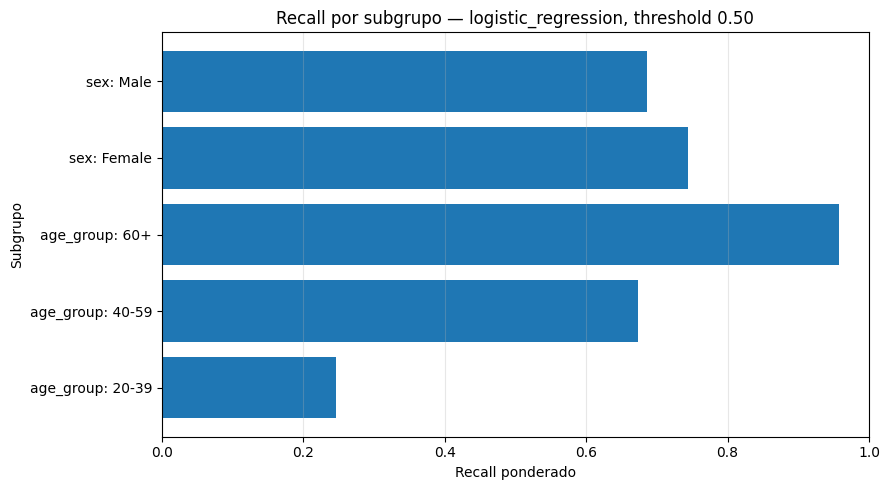


**Explicación del gráfico.** El recall más bajo entre estos subgrupos es `age_group: 20-39` 
(0.246) y el más alto es `age_group: 60+` (0.958). 
Antes de producción se requiere validación más amplia de sesgos, intervalos de confianza con diseño de encuesta y revisión de impacto clínico.


In [31]:
recall_plot_df = subgroup_results.loc[
    subgroup_results["group_variable"].isin(["sex", "age_group"])
]
recall_plot_df = recall_plot_df.sort_values(["group_variable", "group"])
labels = recall_plot_df["group_variable"] + ": " + recall_plot_df["group"]

plt.figure(figsize=(9, 5))
plt.barh(labels, recall_plot_df["recall"])
plt.xlabel("Recall ponderado")
plt.ylabel("Subgrupo")
plt.title(f"Recall por subgrupo — {recommended_model_name}, threshold 0.50")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

min_recall = recall_plot_df.loc[recall_plot_df["recall"].idxmin()]
max_recall = recall_plot_df.loc[recall_plot_df["recall"].idxmax()]
display(Markdown(f"""
**Explicación del gráfico.** El recall más bajo entre estos subgrupos es `{min_recall['group_variable']}: {min_recall['group']}` 
({min_recall['recall']:.3f}) y el más alto es `{max_recall['group_variable']}: {max_recall['group']}` ({max_recall['recall']:.3f}). 
Antes de producción se requiere validación más amplia de sesgos, intervalos de confianza con diseño de encuesta y revisión de impacto clínico.
"""))

## 27. Guardado de artefactos reproducibles

Guardamos:

- subset analítico sin variables prohibidas como features;
- métricas finales;
- resultados de validación;
- tabla de umbrales;
- pipeline recomendado serializado;
- metadata del modelo.

En producción, estos archivos deberían almacenarse en un model registry y un feature store/versionado de datos, no en una carpeta local.

In [32]:
output_dir = Path(".")

analytic_subset_path = output_dir / "metrics" / "nhanes_case1_hypertension_analytic_subset_v1.csv"
metrics_path = output_dir / "metrics" / "nhanes_case1_hypertension_test_metrics_v1.csv"
validation_path = output_dir / "metrics" / "nhanes_case1_hypertension_validation_metrics_v1.csv"
threshold_path = output_dir / "metrics" / "nhanes_case1_hypertension_thresholds_v1.csv"
model_path = (
    output_dir / "metrics" / f"nhanes_case1_hypertension_{recommended_model_name}_pipeline_v1.joblib"
)
metadata_path = output_dir / "metrics" / "nhanes_case1_hypertension_model_metadata_v1.json"

case1_export_cols = (
    ["SEQN", "WTMEC2YR", "SDMVSTRA", "SDMVPSU", "age_group"] + features + [TARGET]
)
case1_subset = adult20[case1_export_cols].copy()
case1_subset.to_csv(analytic_subset_path, index=False)

test_metrics_weighted.to_csv(metrics_path, index=False)
validation_comparison.to_csv(validation_path, index=False)
threshold_df.to_csv(threshold_path, index=False)
joblib.dump(recommended_model, model_path)

metadata = {
    "model_name": recommended_model_name,
    "target": TARGET,
    "features": features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "forbidden_features": forbidden_features,
    "threshold_default": 0.50,
    "threshold_max_f1_validation": max_f1_threshold,
    "threshold_screening_recall_80_validation": screening_threshold,
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn_version,
    "csv_path_used": str(csv_path),
    "rows_raw": int(raw.shape[0]),
    "rows_adult20_eligible": int(adult20.shape[0]),
    "positive_rate_unweighted_adult20": float(adult20[TARGET].mean()),
    "positive_rate_weighted_adult20": float(weighted_positive_rate),
    "primary_test_metrics_weighted": test_metrics_weighted.to_dict(orient="records"),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

## 28. Limitaciones del modelo

1. **No es diagnóstico.** La presión arterial clínica requiere mediciones estandarizadas y evaluación médica.
2. **Diseño transversal.** El modelo estima señales en el mismo momento, no riesgo futuro causal.
3. **Uso parcial de diseño NHANES.** Se usa `WTMEC2YR` como `sample_weight`, pero no se estiman errores estándar con `SDMVSTRA` y `SDMVPSU` dentro de scikit-learn.
4. **Posible sesgo por faltantes.** La imputación dentro del pipeline evita pérdida de filas, pero no elimina sesgo si los faltantes no son aleatorios.
5. **Validación limitada.** Solo hay validación interna; producción requiere validación temporal, externa y clínica.
6. **Variables restringidas.** Se excluyen lecturas de presión como features para evitar fuga; por lo tanto, el modelo infiere señales indirectas y no reemplaza medir presión arterial.
7. **Interpretabilidad no causal.** Coeficientes e importancias son asociaciones condicionadas al dataset y al pipeline.

## 29. Checklist completo para pasar a producción en un ciclo de modelado de sistemas de IA

El siguiente listado usa la estructura **Govern, Map, Measure, Manage** del NIST AI RMF y la traduce a tareas concretas de MLOps/AI Systems Lifecycle.

### A. GOVERN — gobierno, responsabilidades y control

| Estado | Tarea | Entregable mínimo |
|---|---|---|
| ☐ | Nombrar owner clínico, owner de datos, owner técnico y responsable de riesgo | RACI del sistema |
| ☐ | Definir el uso permitido: pre-screening, priorización o investigación; excluir diagnóstico autónomo | Declaración de propósito |
| ☐ | Aprobar política de umbral y acción posterior | Documento clínico-operativo |
| ☐ | Aprobar política de privacidad y seguridad para datos de salud | DPIA/PIA o evaluación equivalente |
| ☐ | Establecer criterios de aceptación del modelo antes de despliegue | Métricas mínimas y criterios de go/no-go |
| ☐ | Crear model card y datasheet del dataset | Documentación versionada |
| ☐ | Definir aprobación humana obligatoria para cualquier intervención clínica | Procedimiento human-in-the-loop |
| ☐ | Revisar obligaciones regulatorias locales | Checklist legal/regulatorio |
| ☐ | Definir proceso de cambios: nuevas variables, nuevo threshold, nuevo modelo | Change management |
| ☐ | Definir plan de incidentes y rollback | Runbook de incidentes |

### B. MAP — contexto, datos, usuarios e impactos

| Estado | Tarea | Entregable mínimo |
|---|---|---|
| ☐ | Mapear población objetivo real y compararla con NHANES | Documento de representatividad |
| ☐ | Confirmar si las variables existen en el sistema fuente productivo | Contrato de datos |
| ☐ | Definir semántica exacta de cada feature productiva | Data dictionary operativo |
| ☐ | Verificar unidades: mg/dL, %, cm, años | Validadores de unidades |
| ☐ | Identificar variables sensibles y subgrupos protegidos | Matriz de atributos sensibles |
| ☐ | Analizar flujos de datos desde captura hasta scoring | Diagrama de arquitectura |
| ☐ | Identificar riesgos: falsos negativos, falsos positivos, sesgos, drift, uso indebido | Registro de riesgos |
| ☐ | Definir usuarios finales y capacitación necesaria | Plan de adopción |
| ☐ | Definir integración con toma de presión confirmatoria | Protocolo operativo |
| ☐ | Definir criterios de exclusión productivos | Reglas de elegibilidad |

### C. MEASURE — validación, desempeño y monitoreo

| Estado | Tarea | Entregable mínimo |
|---|---|---|
| ☐ | Validar con datos externos o prospectivos | Informe de validación externa |
| ☐ | Evaluar ROC-AUC, PR-AUC, precision, recall, F1, Brier y calibración | Reporte de métricas |
| ☐ | Estimar intervalos de confianza con diseño de encuesta cuando aplique | Análisis estadístico complementario |
| ☐ | Evaluar subgrupos por sexo, edad, raza/etnicidad y otros atributos relevantes | Fairness report |
| ☐ | Evaluar calibración por deciles y subgrupos | Calibration report |
| ☐ | Seleccionar threshold con análisis de costos | Documento de threshold |
| ☐ | Medir tasa esperada de alertas por unidad operativa | Capacity planning |
| ☐ | Definir tests unitarios de features y pipeline | Suite de pruebas |
| ☐ | Definir tests de integración del endpoint/batch scoring | CI/CD tests |
| ☐ | Definir monitoreo de data drift, concept drift y performance decay | Monitoreo productivo |
| ☐ | Definir métricas de seguridad: latencia, disponibilidad, errores | SLO/SLA |

### D. MANAGE — despliegue, operación y mejora continua

| Estado | Tarea | Entregable mínimo |
|---|---|---|
| ☐ | Registrar modelo, versión de datos, código y dependencias | Model registry |
| ☐ | Empaquetar pipeline completo, no solo estimador | Artefacto serializado |
| ☐ | Implementar feature validation antes del scoring | Validadores en producción |
| ☐ | Implementar endpoint o batch job con logs auditables | Servicio productivo |
| ☐ | Registrar input schema, output probability, threshold y versión del modelo | Logs trazables |
| ☐ | Implementar explicaciones mínimas para usuarios autorizados | Reporte de razones principales |
| ☐ | Definir fallback si faltan variables críticas | Estrategia de degradación |
| ☐ | Monitorear métricas post-despliegue y alertas | Dashboard |
| ☐ | Revisar falsos negativos/falsos positivos con muestra auditada | Auditoría periódica |
| ☐ | Definir frecuencia de reentrenamiento o gatillos por drift | Política de retraining |
| ☐ | Ejecutar despliegue gradual: shadow, canary o pilot | Plan de rollout |
| ☐ | Mantener rollback automático a versión previa | Plan de reversión |
| ☐ | Revalidar cada cambio de datos, threshold o modelo | Revisión de cambio |
| ☐ | Actualizar documentación y model card por versión | Documentación versionada |

### Decisión final antes de producción

Este modelo puede avanzar a un **piloto controlado** solo si se cumplen estas condiciones mínimas:

1. validación externa o prospectiva aceptable;
2. calibración adecuada para el uso previsto;
3. desempeño por subgrupos sin brechas inaceptables;
4. revisión clínica del umbral y de la acción posterior;
5. monitoreo y rollback implementados;
6. comunicación clara de que el resultado es una señal de riesgo, no un diagnóstico.